# Chapter 19 — Thermal Effects on Strain
### *Modern Strain Gage Technology* — Companion Notebook

**Temperature is the strain gage's most persistent adversary.** A gage bonded to a structure and exposed to a temperature change reports a resistance change even when the structure carries no mechanical load at all.

*Companion notebook to Chapter 19 — Thermal Effects on Strain.*

This *apparent strain* — the chapter's **thermal output** — arises from two sources: the temperature coefficient of resistance of the gage alloy, and the mismatch between the thermal expansion coefficients of the gage grid and the specimen material. When these effects combine unfavorably, apparent strains of hundreds of microstrain over a modest temperature excursion are routine, easily swamping the mechanical signal of interest.

This notebook quantifies thermal output across five common specimen materials, works a numerical example of self-temperature-compensation (STC) mismatch on aluminum, and shows how the dummy-gage technique cancels thermal output at the bridge level — with no post-processing at all.

**This notebook demonstrates:**
1. Apparent strain vs. temperature change for five materials measured with one steel-matched (STC-06) gage
2. STC mismatch error — a steel-matched gage on aluminum over ΔT = −50 to 100 °C
3. Dummy-gage correction — a numerical comparison of quarter-bridge error vs. half-bridge accuracy
4. Thermal output by grid alloy — constantan (A-alloy) vs. modified Karma (K-alloy), after Micro-Measurements TN-504

In [1]:
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# All figures are written here; the book includes these exact filenames.
OUT_DIR = Path("../src/media/ch19")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# This notebook is fully deterministic (no random data), so no seeding is
# required. Every curve below is reproducible byte-for-byte from these inputs.

---
## 1 — Thermal Output vs. Temperature Change

Chapter 19 writes thermal output as the sum of two temperature-driven terms (Eq. 19.4). The first is the temperature coefficient of resistance (TCR) of the grid alloy, divided by the gage factor — the direct resistance change of the grid with temperature. The second is the differential thermal expansion between the specimen and the grid. Because the grid is bonded to the specimen, it is forced to follow the substrate: **if the specimen expands faster than the grid would on its own, the grid is stretched into tension, which *raises* its resistance and registers as positive apparent strain.** In symbols the mismatch term is proportional to $(\alpha_s - \alpha_g)$ — substrate CTE minus grid CTE — exactly the sign the chapter's Eq. 19.4 carries.

A **self-temperature-compensating (STC)** gage exploits this. The alloy is metallurgically processed so that the TCR term and the expansion-mismatch term cancel *for one particular substrate CTE* — the gage's **STC-match CTE**. To first order, the residual thermal output is then simply

$$\varepsilon_{T/O} \approx (\alpha_s - \alpha_{\text{STC}})\,\Delta T,$$

the difference between the actual specimen CTE and the CTE the gage was compensated for. A steel-matched gage (Micro-Measurements STC-06, $\approx 11$ ppm/°C) reads near zero on steel — that is the whole point — but bond it to aluminum ($\alpha \approx 23$ ppm/°C) and the mismatch term dominates, piling up apparent strain as the temperature moves. The curves below make that contrast concrete: the matched material sits on the zero line, everything else fans out.

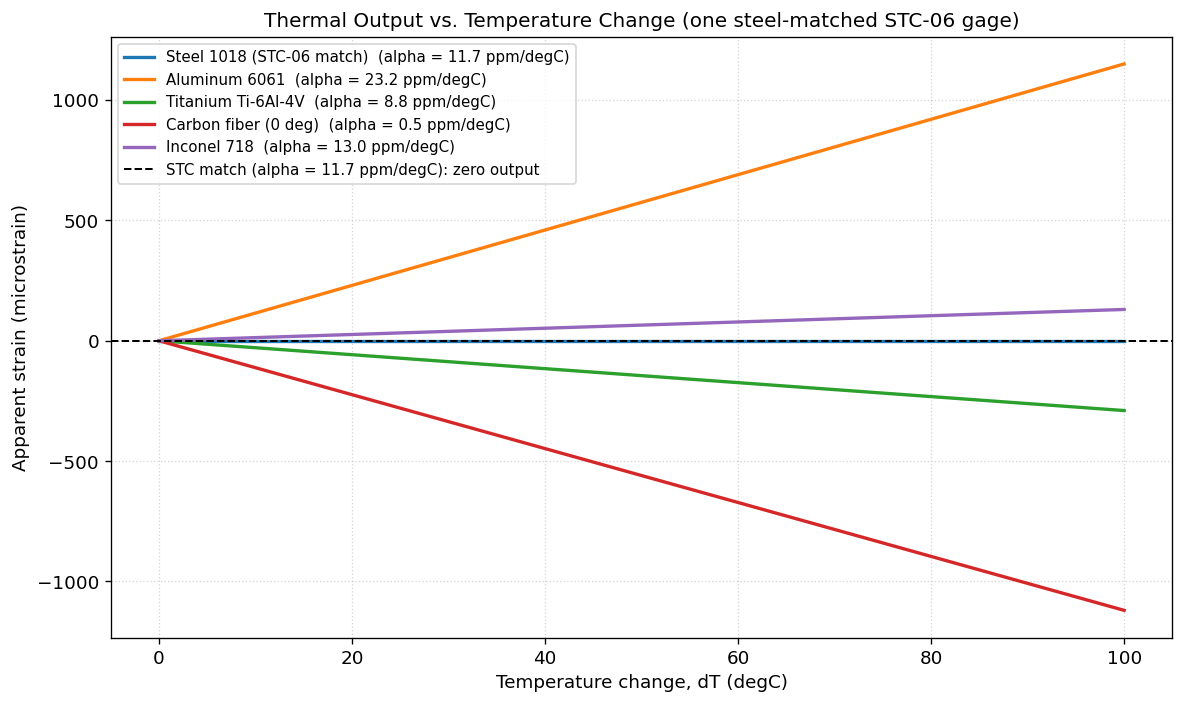

In [2]:
# --- Model ---------------------------------------------------------------
# First-order thermal output of a self-temperature-compensated (STC) gage.
# See Chapter 19, Eq. 19.4 and Micro-Measurements TN-504.

def thermal_output(alpha_specimen, alpha_stc_match, dT):
    """Apparent strain (thermal output) of an STC gage, in microstrain.

    For a self-temperature-compensated gage the grid's TCR term and its
    expansion-mismatch term are metallurgically tuned to cancel when the
    substrate CTE equals the gage's STC-match CTE. To first order the
    residual thermal output is therefore proportional to how far the actual
    specimen CTE sits from that match point:

        eps_T/O ~= (alpha_specimen - alpha_stc_match) * dT      [microstrain]

    Note the sign: when the specimen expands faster than the matched grid
    (alpha_specimen > alpha_stc_match), the grid is stretched and apparent
    strain is positive (cf. Eq. 19.4, whose mismatch term is alpha_s - alpha_g).

    Parameters
    ----------
    alpha_specimen  : float      specimen CTE (ppm/degC)
    alpha_stc_match : float      CTE the gage is compensated for (ppm/degC)
    dT              : array-like temperature change from balance point (degC)

    Returns
    -------
    numpy.ndarray : apparent strain (microstrain, i.e. ppm)
    """
    return (alpha_specimen - alpha_stc_match) * np.asarray(dT, dtype=float)


# --- Inputs --------------------------------------------------------------
# One steel-matched constantan gage (Micro-Measurements STC-06) measured on
# five substrates. STC-06 compensates for ~11 ppm/degC; we idealize the match
# to steel's CTE so the steel curve lands exactly on zero.
STEEL_STC_MATCH_CTE = 11.7   # ppm/degC  (gage's STC-match CTE; ~STC-06)
DELTA_T_MAX_C       = 100.0  # degC      temperature rise plotted

# Specimen coefficients of thermal expansion (ppm/degC)
specimen_CTE = {
    'Steel 1018 (STC-06 match)': 11.7,
    'Aluminum 6061':             23.2,
    'Titanium Ti-6Al-4V':         8.8,
    'Carbon fiber (0 deg)':       0.5,
    'Inconel 718':               13.0,
}

dT = np.linspace(0.0, DELTA_T_MAX_C, 200)  # degC

fig, ax = plt.subplots(figsize=(10, 6))
for name, alpha_s in specimen_CTE.items():
    eps_app = thermal_output(alpha_s, STEEL_STC_MATCH_CTE, dT)  # microstrain
    ax.plot(dT, eps_app, lw=2, label=f'{name}  (alpha = {alpha_s} ppm/degC)')

# The matched material rides the zero line: this is the STC design condition.
ax.axhline(0, color='black', lw=1.2, ls='--',
           label=f'STC match (alpha = {STEEL_STC_MATCH_CTE} ppm/degC): zero output')
ax.set_xlabel('Temperature change, dT (degC)')
ax.set_ylabel('Apparent strain (microstrain)')
ax.set_title('Thermal Output vs. Temperature Change (one steel-matched STC-06 gage)')
ax.legend(fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig19_nb1_thermal_output_materials.png',
            bbox_inches='tight', dpi=150)
plt.show()

---
## 2 — STC Mismatch — Worked Example

The **STC number** stamped on a gage package encodes the CTE of the material the gage was compensated for. In the Micro-Measurements convention it is given in ppm/°F: **STC-06** suits carbon and alloy steels (≈ 11 ppm/°C), while **STC-13** suits aluminum alloys (≈ 23 ppm/°C). Choosing STC-06 for a steel specimen minimizes apparent strain over the rated range. Install that same steel-matched gage on an aluminum specimen (CTE ≈ 23.2 ppm/°C) and you introduce a CTE mismatch of about **11.5 ppm/°C**, which generates roughly **11.5 µε per °C** of apparent strain — a **575 µε** error at ΔT = 50 °C.

The shaded region in the figure is that error. At ΔT = 50 °C it equals the strain produced by about **115 MPa** of stress in steel — a systematic offset that no amount of signal amplification can remove once it has entered the measurement. The remedy is not electronics but gage selection: match the STC number to the actual test material (an STC-13 gage on this aluminum would ride the zero line).

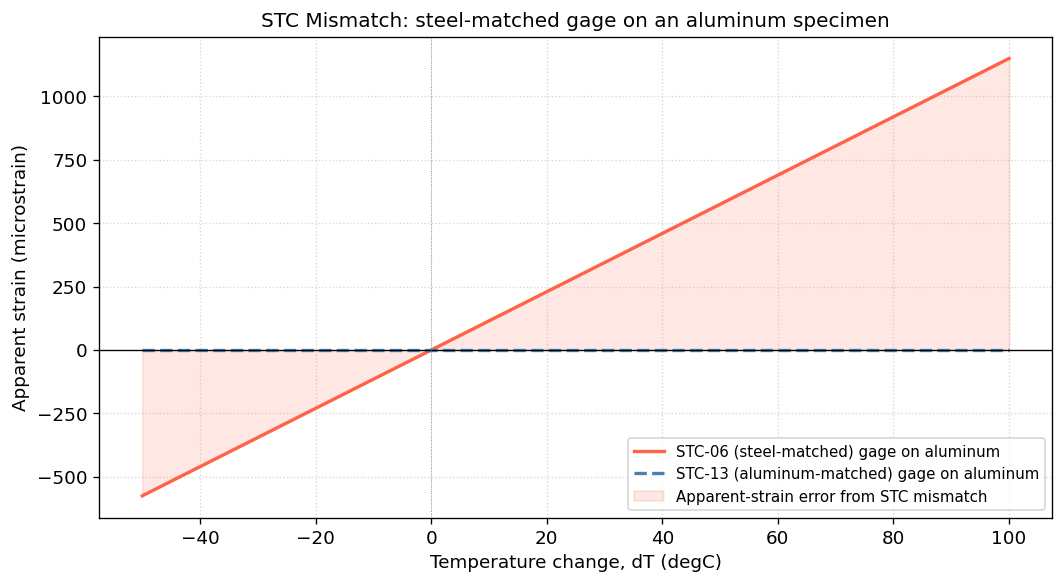

CTE mismatch: 11.5 ppm/degC -> 11.5 microstrain per degC
At dT = 50 degC, STC mismatch introduces 575 microstrain of apparent strain.
That equals the strain from about 115 MPa of stress in steel -- a significant error.


In [3]:
# Steel-matched (STC-06) gage vs. aluminum-matched (STC-13) gage, both on an
# aluminum specimen. The steel-matched gage is mismatched to the substrate and
# accumulates apparent strain; the aluminum-matched gage rides the zero line.
STEEL_STC_MATCH_CTE = 11.7   # ppm/degC  (STC-06)
AL_STC_MATCH_CTE    = 23.2   # ppm/degC  (STC-13, matched to this specimen)
ALUMINUM_CTE        = 23.2   # ppm/degC  (6061 specimen)
E_STEEL_MPA         = 200e3  # MPa       for the equivalent-stress comparison

dT = np.linspace(-50.0, 100.0, 300)  # degC
eps_mismatch = thermal_output(ALUMINUM_CTE, STEEL_STC_MATCH_CTE, dT)  # microstrain
eps_matched  = thermal_output(ALUMINUM_CTE, AL_STC_MATCH_CTE,    dT)  # ~0

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(dT, eps_mismatch, 'tomato', lw=2,
        label='STC-06 (steel-matched) gage on aluminum')
ax.plot(dT, eps_matched, 'steelblue', lw=2, ls='--',
        label='STC-13 (aluminum-matched) gage on aluminum')
ax.axhline(0, color='black', lw=0.8)
ax.axvline(0, color='gray', lw=0.5, ls=':')
ax.fill_between(dT, eps_mismatch, eps_matched, alpha=0.15, color='tomato',
                label='Apparent-strain error from STC mismatch')
ax.set_xlabel('Temperature change, dT (degC)')
ax.set_ylabel('Apparent strain (microstrain)')
ax.set_title('STC Mismatch: steel-matched gage on an aluminum specimen')
ax.legend(fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig19_nb2_stc_mismatch.png', bbox_inches='tight', dpi=150)
plt.show()

DT_EXAMPLE_C = 50.0
err_ue = abs(thermal_output(ALUMINUM_CTE, STEEL_STC_MATCH_CTE, DT_EXAMPLE_C))  # microstrain
equiv_stress_MPa = (err_ue * 1e-6) * E_STEEL_MPA
print(f"CTE mismatch: {ALUMINUM_CTE - STEEL_STC_MATCH_CTE:.1f} ppm/degC "
      f"-> {ALUMINUM_CTE - STEEL_STC_MATCH_CTE:.1f} microstrain per degC")
print(f"At dT = {DT_EXAMPLE_C:.0f} degC, STC mismatch introduces {err_ue:.0f} microstrain of apparent strain.")
print(f"That equals the strain from about {equiv_stress_MPa:.0f} MPa of stress in steel -- a significant error.")

---
## 3 — Temperature Correction Using a Dummy Gage

The dummy gage technique places a second, identical gage on an unstressed piece of the same specimen material, in the same thermal environment as the active gage. Both gages experience the same temperature change and therefore produce the same apparent strain. When wired in adjacent bridge arms (half-bridge configuration), the apparent strains subtract — leaving only the mechanical strain in the active gage.

The calculation below makes this concrete with numbers: 100 με of true mechanical strain buried under 200 με of thermal apparent strain. Without the dummy, the quarter-bridge reads 300 με — a 200% error. With the dummy half-bridge, the reading is exactly 100 με. No mathematical correction is required; the cancellation is built into the bridge circuit itself.

In [4]:
# Dummy-gage (half-bridge) thermal compensation.
#   Active gage: delta_R/R = GF * (eps_mech + eps_thermal)
#   Dummy gage:  delta_R/R = GF * (0        + eps_thermal)   [same T, no load]
# Wired in adjacent bridge arms, the two apparent strains subtract at the node,
# leaving only the active gage's mechanical strain -- no math correction needed.

EPS_MECH_UE     = 100   # microstrain  true mechanical strain in the active gage
EPS_APPARENT_UE = 200   # microstrain  thermal output shared by both gages


def bridge_readings(eps_mech, eps_apparent):
    """Return (quarter_bridge, half_bridge) indicated strain in microstrain.

    The quarter bridge (single active gage) reads mechanical + thermal output.
    The half bridge with a dummy gage cancels the common thermal output at the
    adjacent bridge arm, so it reads the mechanical strain alone.
    """
    quarter_bridge = eps_mech + eps_apparent   # thermal output not removed
    half_bridge    = eps_mech                  # dummy cancels thermal output
    return quarter_bridge, half_bridge


eps_qb, eps_hb = bridge_readings(EPS_MECH_UE, EPS_APPARENT_UE)
error_ue = eps_qb - EPS_MECH_UE

print("Thermal output correction -- dummy gage technique:")
print(f"  True mechanical strain:       {EPS_MECH_UE:6.0f} microstrain")
print(f"  Thermal apparent strain:      {EPS_APPARENT_UE:6.0f} microstrain")
print(f"  Quarter bridge (reads):       {eps_qb:6.0f} microstrain  <- ERROR")
print(f"  Half bridge with dummy:       {eps_hb:6.0f} microstrain  <- CORRECT")
print(f"  Error without correction:     {error_ue:6.0f} microstrain "
      f"({error_ue / EPS_MECH_UE * 100:.0f}%)")

Thermal output correction -- dummy gage technique:
  True mechanical strain:          100 microstrain
  Thermal apparent strain:         200 microstrain
  Quarter bridge (reads):          300 microstrain  <- ERROR
  Half bridge with dummy:          100 microstrain  <- CORRECT
  Error without correction:        200 microstrain (200%)


---
## 4 — Thermal Output by Gage Alloy: A-alloy vs K-alloy

Self-temperature compensation cancels the TCR and expansion-mismatch terms only approximately, and only over a limited range. The residual thermal output is a smooth, nonlinear function of temperature whose shape depends on the grid alloy. Constantan (A-alloy) and modified Karma (K-alloy) are the two principal STC alloys: A-alloy is near-zero over a narrow band around the reference but climbs steeply at temperature extremes, while K-alloy stays much flatter over a wider range — the reason it is preferred for transducers and wide-temperature work. The curves below reproduce the characteristic shapes for both alloys on a 1018 steel specimen, after Micro-Measurements TN-504.

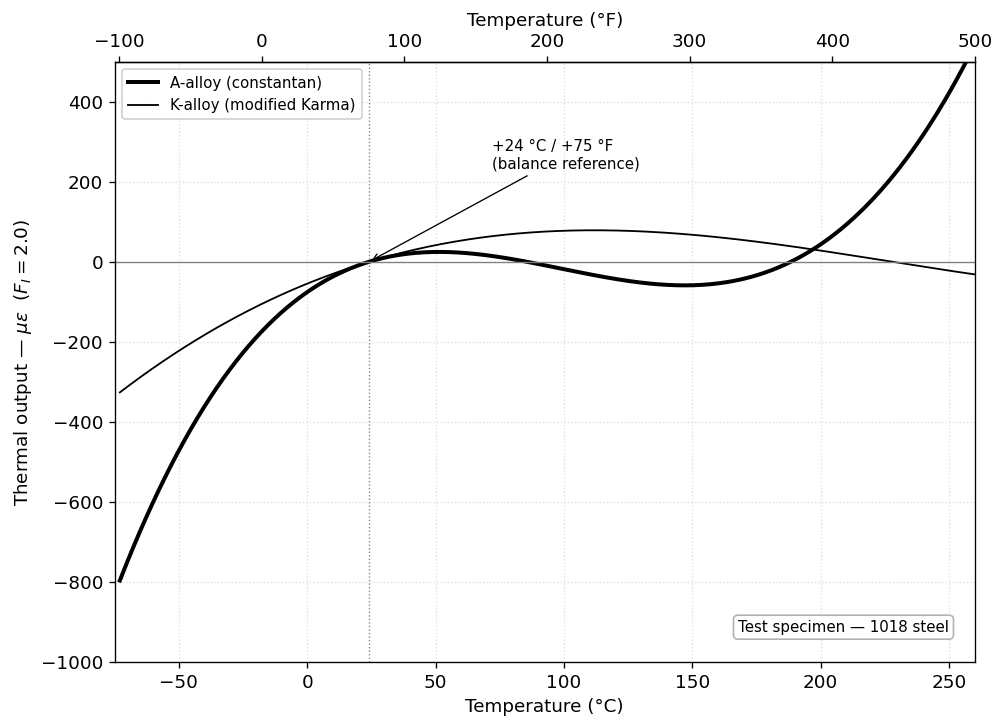

In [5]:
# A-alloy vs K-alloy thermal output on 1018 steel (after Micro-Measurements TN-504).
# Self-temperature-compensated constantan (A-alloy) and modified Karma (K-alloy).
# Curves are representative of the characteristic TN-504 shapes; actual thermal
# output is lot-, alloy-, and installation-specific.

Tref_C = 24.0  # reference temperature (zero thermal output)

# Representative points tracing the canonical shapes (deg C, microstrain)
TA = np.array([-73, -40,   0,  24,  45,  80, 135, 175, 205, 232, 260])
EA = np.array([-840,-470,-150,   0, -30, -95,-125, -90,   0, 200, 470])
TK = np.array([-129, -73, -20,  24,  70, 120, 165, 205, 245, 260])
EK = np.array([-650,-340, -90,   0,  55,  80,  65,  25, -15, -30])

cA = np.polyfit(TA - Tref_C, EA, 4)
cK = np.polyfit(TK - Tref_C, EK, 4)

T = np.linspace(-73, 260, 400)
yA = np.polyval(cA, T - Tref_C) - np.polyval(cA, 0.0)
yK = np.polyval(cK, T - Tref_C) - np.polyval(cK, 0.0)

c2f = lambda c: c * 9/5 + 32
f2c = lambda f: (f - 32) * 5/9

fig, ax = plt.subplots(figsize=(8.5, 6.2))
ax.plot(T, yA, 'k-', lw=2.4, label='A-alloy (constantan)')
ax.plot(T, yK, 'k-', lw=1.1, label='K-alloy (modified Karma)')
ax.axhline(0, color='0.5', lw=0.8)
ax.axvline(Tref_C, color='0.5', lw=0.8, ls=':')
ax.annotate('+24 °C / +75 °F\n(balance reference)', xy=(Tref_C, 0),
            xytext=(72, 235), fontsize=9, arrowprops=dict(arrowstyle='->', lw=0.8))
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel(r'Thermal output — $\mu\varepsilon$  ($F_I = 2.0$)')
ax.set_xlim(-75, 260); ax.set_ylim(-1000, 500)
ax.grid(True, ls=':', alpha=0.4)
secax = ax.secondary_xaxis('top', functions=(c2f, f2c))
secax.set_xlabel('Temperature (°F)')
ax.text(0.97, 0.05, 'Test specimen — 1018 steel', transform=ax.transAxes,
        ha='right', fontsize=9, bbox=dict(boxstyle='round', fc='white', ec='0.7'))
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig19_nb3_thermal_output_alloys.png', bbox_inches='tight', dpi=150)
plt.show()


---
## Where to take this next

This notebook uses the first-order STC approximation, $\varepsilon_{T/O} \approx (\alpha_s - \alpha_{\text{STC}})\,\Delta T$. Real thermal output is nonlinear and lot-specific. Three concrete extensions:

1. **Fit a real thermal-output polynomial.** Micro-Measurements ships each gage lot with a cubic thermal-output curve, $\varepsilon_{T/O} = a_0 + a_1 T + a_2 T^2 + a_3 T^3$. Replace the linear model with a cubic, then differentiate it to plot the local slope (µε/°C) and find the temperature where thermal output is most sensitive — the worst place to operate an uncompensated gage.

2. **Add gage-factor drift.** Layer the multiplicative correction of Eq. 19.6 on top of the additive thermal-output subtraction and reproduce the chapter's two-step worked example (425 µε → 315 µε → 322 µε). Show how the two corrections compound as a function of temperature.

3. **Model a real dummy-gage mismatch.** Section 3 assumes the dummy sees exactly the active gage's thermal output. Break that assumption: give the dummy a small temperature offset or a slightly different lot curve, and quantify how much residual apparent strain leaks through — the practical limit the chapter warns about for gradients and transients.